# PCA Workshop: Principal Component Analysis from Scratch

**Time:** ~90 minutes

### The Big Picture
In the neural network workshop you used `PCA` from scikit-learn to squash 32-dimensional embeddings down to 2 so you could plot them — but the algorithm itself stayed a black box. Today you'll open the box: using nothing but NumPy, you'll build PCA yourself, step by step, and then prove your version produces exactly the same answer as scikit-learn's. We're back on familiar ground — the iris dataset, where each flower is described by 4 measurements. Four numbers per flower means the data lives in 4 dimensions; by the end you'll have compressed it to 2 while keeping ~96% of the information. We'll do it in 6 steps:

1. Load the data and standardize it
2. Compute the covariance matrix
3. Find the principal directions (eigendecomposition)
4. Sort the components & measure explained variance
5. Project the data from 4D down to 2D
6. Verify your implementation against scikit-learn

### Before we start: get the data
Run the two cells below. The first loads the libraries — note that we import scikit-learn's `PCA` only so we can check our work at the very end; every other step today is pure NumPy. The second loads the iris dataset, the same 150 flowers you clustered in the k-means workshop. (Yes, it still contains the duplicate row you hunted down back then — one duplicated flower barely nudges the variance structure, so today we keep all 150.)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA  # only for checking our work at the very end!

print("Ready to go!")

Ready to go!


In [4]:
iris_bunch = load_iris(as_frame=True)
iris = iris_bunch.frame.copy()
iris["species"] = iris["target"].map(dict(enumerate(iris_bunch.target_names)))
iris = iris.drop(columns=["target"])
iris.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]

features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
X = iris[features].to_numpy()          # (150, 4) array of measurements
species = iris["species"].to_numpy()   # (150,) species name for each flower

print("Loaded iris:", X.shape)

Loaded iris: (150, 4)


---
## Question 1: Standardize the Data

PCA hunts for the directions in which the data is most *spread out* — directions of maximum variance. That makes it sensitive to units: a feature measured in millimeters would have 100x the spread of the same feature in centimeters and would dominate the analysis for no good reason. So the first step is always to put every feature on the same footing: subtract each feature's mean and divide by its standard deviation, so that every column ends up with mean 0 and standard deviation 1.

$$x' = \frac{x - \bar{x}}{\sigma_x}$$

(You've seen scaling matter before — the clustering workshop's bonus hinted that k-means behaves differently on unscaled features. Same idea here.)

**Your tasks:**
1. Compute the per-feature means and standard deviations of `X` (hint: these are NumPy array methods, and you'll want `axis=0` so you get one value per column).
2. Write a function `standardize(X)` that applies the formula above to every feature.
3. Apply it to get `X_std`, then verify that each column of `X_std` now has mean ≈ 0 and standard deviation 1.

In [5]:
# TODO: per-feature means and stds of X (one value per column)
feature_means = X.mean(axis=0)
feature_stds =  X.std(axis=0)

# TODO: write standardize(X) using the formula from the question above
def standardize(X):
     return (X - X.mean(axis=0)) / X.std(axis=0)

# TODO: apply it to X
X_std = standardize(X)

print("Feature means before:", np.round(feature_means, 3))
print("Feature stds before: ", np.round(feature_stds, 3))
print("Means after: ", np.round(X_std.mean(axis=0), 3))
print("Stds after:  ", np.round(X_std.std(axis=0), 3))

Feature means before: [5.843 3.057 3.758 1.199]
Feature stds before:  [0.825 0.434 1.759 0.76 ]
Means after:  [-0. -0. -0. -0.]
Stds after:   [1. 1. 1. 1.]


**Check your work:** Before standardizing, the means should be about `[5.843, 3.057, 3.758, 1.199]` and the stds about `[0.825, 0.434, 1.759, 0.76]` — notice how unequal those spreads are, which is exactly why we standardize. After standardizing, every mean should print as `0.0` or `-0.0` (floating-point's way of saying "zero") and every std as exactly `1.0`.

---
## Question 2: The Covariance Matrix

Variance measures how much a single feature spreads around its mean. **Covariance** extends that to *pairs* of features: it's positive when two features tend to be above (or below) their means together, negative when one runs high while the other runs low, and near zero when they don't track each other at all. The covariance matrix collects all of these at once — entry (i, j) is the covariance between feature i and feature j, so the diagonal holds each feature's variance with itself.

Because `X_std` already has mean 0 in every column, the whole thing collapses to one tidy expression:

$$C = \frac{X^\top X}{n - 1}$$

**Your tasks:**
1. Write a function `covariance(X)` that computes the formula above — it comes down to one matrix multiplication (the `@` operator) and a division.
2. Apply it to `X_std` and print the resulting 4x4 matrix `cov_mat`.
3. Verify your matrix against NumPy's built-in `np.cov` (two hints: `np.cov` expects features in *rows*, so pass it the transpose; and `np.allclose` is the standard way to compare two float arrays).
4. In a short comment: which pair of *different* features covaries most strongly? Does that match the correlation ranking you computed in the clustering workshop?

In [6]:
# TODO: write covariance(X) using the formula from the question above
def covariance(X):
     return (X.T @ X) / (X.shape[0] - 1)

# TODO: apply it to X_std
cov_mat = covariance(X_std)

print("Covariance matrix (rounded):")
print(pd.DataFrame(np.round(cov_mat, 3), index=features, columns=features))

# TODO: verify against NumPy's built-in np.cov -- should print True
print("\nMatches np.cov:", np.allclose(cov_mat, np.cov(X_std.T)))

# TODO (comment): which pair of different features covaries most strongly?
# The petal width and petal length seem to covary most strongly with 0.969, and they also had the most correlation in the clustering

Covariance matrix (rounded):
              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.007       -0.118         0.878        0.823
sepal_width         -0.118        1.007        -0.431       -0.369
petal_length         0.878       -0.431         1.007        0.969
petal_width          0.823       -0.369         0.969        1.007

Matches np.cov: True


**Check your work:** `cov_mat` should be 4x4 and symmetric, with about `1.007` down the diagonal — not exactly 1, because we standardized dividing by `n` but covariance divides by `n - 1`, so the diagonal is `150/149`. The `np.allclose` check should print `True`. The strongest off-diagonal pair is `petal_length` & `petal_width` at about `0.97` — the same two features that topped the correlation ranking in the clustering workshop.

---
## Question 3: Find the Principal Directions (Eigendecomposition)

Here's the heart of PCA. We want the directions along which the data varies most, and it turns out those are exactly the **eigenvectors** of the covariance matrix. An eigenvector of a matrix $C$ is a special direction that $C$ doesn't rotate — it only stretches it, and the stretch factor is the **eigenvalue** $\lambda$:

$$C v = \lambda v$$

For a covariance matrix specifically: each eigenvector is a direction in feature space (a "principal component"), and its eigenvalue is the variance of the data along that direction. Bigger eigenvalue = more of the data's spread lives along that direction.

You don't have to implement the decomposition itself — that's a deep rabbit hole of numerical linear algebra — `np.linalg.eig` does it in one call. It returns the eigenvalues, plus a matrix whose **columns** (not rows!) are the eigenvectors.

**Your tasks:**
1. Run `np.linalg.eig` on `cov_mat` to get `eig_vals` and `eig_vecs`.
2. Verify the defining equation for the first eigenpair: pull out the first eigenvalue and its matching eigenvector (careful — eigenvectors are *columns*), compute each side of $Cv = \lambda v$, and check that the two sides agree (`np.allclose` again).
3. Verify that the eigenvalues sum to the total variance in the data — the sum of the diagonal of `cov_mat`, also called its **trace** (hint: NumPy has a function for that).

In [7]:
# TODO: eigendecomposition of cov_mat
eig_vals, eig_vecs = np.linalg.eig(cov_mat)
print("Eigenvalues:", np.round(eig_vals, 4))

# TODO: first eigenvalue and its matching eigenvector, then verify C v = lambda v
v = eig_vecs[:, 0]
lam = eig_vals[0]
print("C @ v equals lambda * v:", np.allclose(cov_mat @ v, lam * v))

# TODO: compare the sum of the eigenvalues to the trace of cov_mat
print("Sum of eigenvalues:", round(eig_vals.sum(), 4))
print("Total variance (trace):", round(np.trace(cov_mat), 4))

Eigenvalues: [2.9381 0.9202 0.1477 0.0209]
C @ v equals lambda * v: True
Sum of eigenvalues: 4.0268
Total variance (trace): 4.0268


**Check your work:** The eigenvalues should be about `[2.938, 0.92, 0.148, 0.021]` — possibly in a different order, since `np.linalg.eig` makes no ordering promise (that's what Question 4 is for). The `C @ v = λv` check should print `True`, and the eigenvalues should sum to about `4.027`, exactly matching the trace of `cov_mat` (it's `4 × 150/149`). Nothing about the total spread was lost — eigendecomposition just splits it across four new directions.

---
## Question 4: Sort the Components & Explained Variance

`np.linalg.eig` doesn't guarantee any ordering, so first we sort the eigenpairs by eigenvalue, largest first — that makes eigenvector #1 the direction with the most variance ("PC1"), and so on. **Careful:** eigenvalues and eigenvectors must stay matched up when you reorder, and eigenvectors are the *columns* of `eig_vecs` — so reorder its columns, not its rows.

Once sorted, each eigenvalue divided by the sum of them all is that component's **explained variance ratio** — the fraction of the total spread it captures. This is exactly the `explained_variance_ratio_` you printed from sklearn's PCA in the MNIST workshop; now you get to compute it yourself.

**Your tasks:**
1. Build `eig_vals_sorted` and `eig_vecs_sorted`, ordered so the largest eigenvalue comes first (hint: `np.argsort` gives you the *ascending* order — you'll need to reverse it, then use the same indices to reorder the eigenvector columns).
2. Compute `explained_var_ratio` — each sorted eigenvalue as a fraction of their total — and `cumulative_var`, its running total (hint: `np.cumsum`).
3. Plot both per component: a bar chart of the individual ratios, with a line for the cumulative on top.
4. Store in `n_components_95` the number of components needed to keep at least 95% of the variance.

Explained variance ratio (%): [72.96 22.85  3.67  0.52]
Cumulative (%): [ 72.96  95.81  99.48 100.  ]


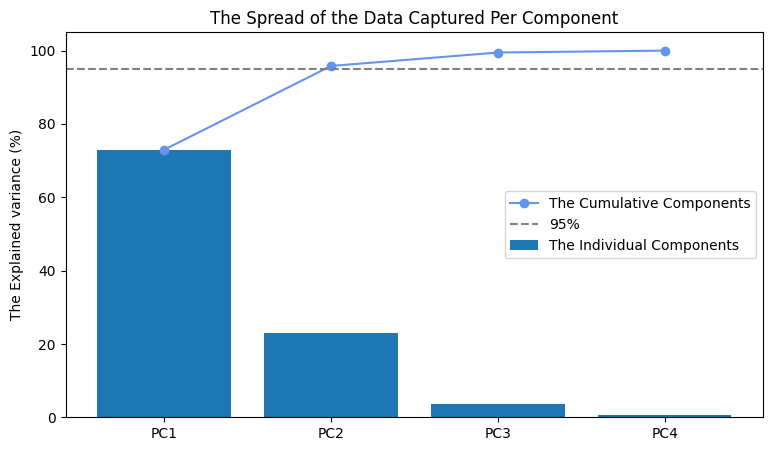

Components needed for 95%: 2


In [8]:
# TODO: indices that put eig_vals in DESCENDING order
order = np.argsort(eig_vals)[::-1]
# TODO: sorted eigenvalues, and eigenvectors with their COLUMNS reordered to match
eig_vals_sorted = eig_vals[order]
eig_vecs_sorted = eig_vecs[:, order]


# TODO: explained variance ratio and its cumulative sum
explained_var_ratio =  eig_vals_sorted / eig_vals_sorted.sum()
cumulative_var =  np.cumsum(explained_var_ratio)

print("Explained variance ratio (%):", np.round(explained_var_ratio * 100, 2))
print("Cumulative (%):", np.round(cumulative_var * 100, 2))

# TODO: bar chart of the individual ratios + a line for the cumulative
cs = np.arange(1, len(explained_var_ratio) + 1)
plt.figure(figsize=(9, 5))
plt.bar(cs, explained_var_ratio * 100, label="The Individual Components")
plt.plot(cs, cumulative_var * 100, marker="o", color="cornflowerblue", label="The Cumulative Components")
plt.axhline(95, linestyle="--", color="gray", label="95%")
plt.xticks(cs, [f"PC{i}" for i in cs])
plt.ylabel("The Explained variance (%)")
plt.title("The Spread of the Data Captured Per Component")
plt.legend()
plt.show()

# TODO: how many components to keep at least 95% of the variance?
n_components_95 = int(np.argmax(cumulative_var >= 0.95) + 1)
print("Components needed for 95%:", n_components_95)

**Check your work:** Explained variance should be about `72.96%, 22.85%, 3.67%, 0.52%` for PC1 through PC4, with cumulative `72.96, 95.81, 99.48, 100.0`. So `n_components_95` should be `2` — the first two directions alone keep 95.81% of the variance, which is why squashing 4D iris down to a 2D plot is nearly lossless.

---
## Question 5: Project Down to 2D

Time to actually compress the data. Stack the top-2 eigenvectors side by side into a projection matrix $W$ (shape 4x2), and multiply:

$$X_{proj} = X_{std}\,W$$

Each flower goes in as 4 standardized measurements and comes out as just 2 numbers — its coordinates along PC1 and PC2. This is precisely what `fit_transform` did to your MNIST embeddings.

**Your tasks:**
1. Build `W` from the first two columns of `eig_vecs_sorted` — check that its shape is `(4, 2)`.
2. Project the standardized data using the formula above — check that the result `X_proj` has shape `(150, 2)`.
3. Scatter plot PC1 vs PC2, colored by species (loop over `np.unique(species)`, the same way you looped over groups in the clustering workshop).
4. In a short comment: how well do the three species separate in this 2D view, and which ones still overlap?

In [9]:
# TODO: projection matrix W = the first two columns of eig_vecs_sorted
W = eig_vecs_sorted[:, :2]
print("W shape:", W.shape)

# TODO: project the standardized data down to 2D
X_proj = X_std @ W
print("Projected shape:", X_proj.shape)
print("First flower in PC space:", np.round(X_proj[0], 4))

W shape: (4, 2)
Projected shape: (150, 2)
First flower in PC space: [-2.2647 -0.48  ]


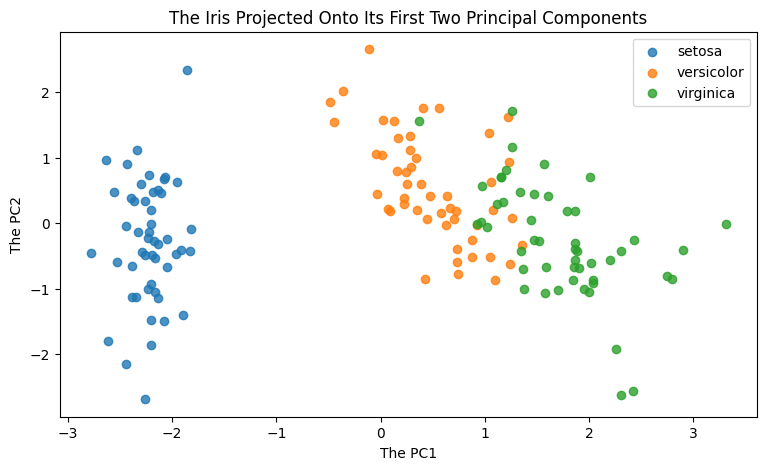

In [10]:
# TODO: scatter plot PC1 vs PC2, one color per species (loop over np.unique(species))
plt.figure(figsize=(9, 5))
for name in np.unique(species):
    mask = species == name
    plt.scatter(X_proj[mask, 0], X_proj[mask, 1], label=name, alpha=0.8)
plt.xlabel("The PC1")
plt.ylabel("The PC2")
plt.title("The Iris Projected Onto Its First Two Principal Components")
plt.legend()
plt.show()

# TODO (comment): how well do the three species separate? which ones overlap?
# The setosa iris separates but

**Check your work:** `W` should be `(4, 2)` and `X_proj` should be `(150, 2)`, with the first flower landing at about `(-2.26, -0.48)` — though either coordinate may come out with its sign flipped on your machine: if $v$ is an eigenvector then so is $-v$, and both describe the same axis. In the plot, setosa should sit on its own well-separated island along PC1, while versicolor and virginica form two adjacent groups with mild overlap — the same structure your petal scatter plots and k-means clusters revealed, except PCA found it with no labels and no hand-picking of features.

---
## Question 6 (Capstone): Verify Against scikit-learn

The moment of truth. If your implementation is right, it should agree with `sklearn.decomposition.PCA` — the industrial-strength version you used in the MNIST workshop — down to floating-point noise. One wrinkle: because $v$ and $-v$ are both valid eigenvectors, an entire PC column can come out sign-flipped between two implementations. That's not an error; it's the same axis, just mirrored.

**Your tasks:**
1. Fit `PCA(n_components=2)` on `X_std` and get `sklearn_proj` from `fit_transform` (exactly like the MNIST workshop).
2. Compare its `explained_variance_ratio_` against the first two entries of your `explained_var_ratio`.
3. Check that the two projections agree *up to sign*: compare their absolute values (hint: `np.abs` and `np.allclose`).
4. For each of the two PCs, print whether your column matches sklearn's exactly or comes out flipped.

In [11]:
# TODO: fit PCA(n_components=2) on X_std and project with fit_transform
sklearn_pca = PCA(n_components=2)
sklearn_proj = sklearn_pca.fit_transform(X_std)

print("Ours    (%):", np.round(explained_var_ratio[:2] * 100, 2))
print("Sklearn (%):", np.round(sklearn_pca.explained_variance_ratio_ * 100, 2))

print("\nFirst flower, ours:   ", np.round(X_proj[0], 4))
print("First flower, sklearn:", np.round(sklearn_proj[0], 4))

# TODO: same projection up to sign flips? (compare the absolute values)
same_up_to_sign = np.allclose(np.abs(X_proj), np.abs(sklearn_proj))
print("\nSame projection up to sign flips:", same_up_to_sign)

# TODO: for each PC, print whether your column matches sklearn's exactly or is flipped

Ours    (%): [72.96 22.85]
Sklearn (%): [72.96 22.85]

First flower, ours:    [-2.2647 -0.48  ]
First flower, sklearn: [-2.2647  0.48  ]

Same projection up to sign flips: True


**Check your work:** The explained variance ratios should match to every printed decimal (`72.96%, 22.85%`), and the up-to-sign comparison should print `True`. In our run PC1 matched exactly and PC2 came out flipped — yours may differ depending on library versions, and any combination of flips still counts as a perfect match. Either way: you've just re-derived scikit-learn's PCA from scratch.

**Your reflection (2-3 sentences):** In the MNIST workshop you called `PCA(n_components=2)` on 32-dimensional embeddings without knowing what was inside. Walk through what actually happened to those embeddings, step by step, in terms of what you built today. Going from 32 dimensions to 2 there, would you expect the discarded variance to be closer to the ~4% you lost here — and how would you check?

The discarded variance may not be as close to 4%, as there are significantly less dimensions. Furthermore, variance would be spread across all of the different PCA dimensions, not just two of them. You would check the variance likely by running variance functions on the dimensions, and checking how much data is dropepd as they are reduced.

### Bonus (if you finish early)
- Rerun the whole pipeline on the **raw, unstandardized** `X`. Which feature dominates PC1 now, and why? (Look back at the feature stds from Question 1.)
- Go backwards: reconstruct the data with `X_approx = X_proj @ W.T` and measure the mean squared error against `X_std`. Then try keeping 1, 3, and 4 components instead of 2 — how does the reconstruction error relate to the eigenvalues you discarded?
- Wrap Questions 1-5 into a single function `my_pca(X, k)` that returns the projected data and the explained variance ratios — then drop it into your MNIST notebook in place of sklearn's PCA and confirm the digit-cluster plot still looks the same.
- We used `np.linalg.eig`, but scikit-learn actually computes PCA via the **singular value decomposition** (`np.linalg.svd`) — faster and numerically steadier. Look up how the SVD of `X_std` relates to the eigendecomposition of its covariance matrix, and get the same projection a third way.